In [1]:
import pickle
from matplotlib import pyplot as plt
import numpy as np

In [2]:
def plot(ax, filename, maxd, maxp, normalise=True):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/LR_param_exploration.no_shot_noise.{filename}.d{maxd}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    deltas = res['deltas']
    ps = res['ps']
    energies = np.array(energies)
    if normalise:
        # energies /= energies.max()
        energies /= energies[0,0]
    im = ax.pcolormesh(ps, deltas, energies.T, shading='nearest')
    cbar = ax.figure.colorbar(im, ax=ax)
    label = '$\\frac{H_C}{\\max(H_C)}$' if normalise else '${H_C}$'
    cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=25)
    return ax

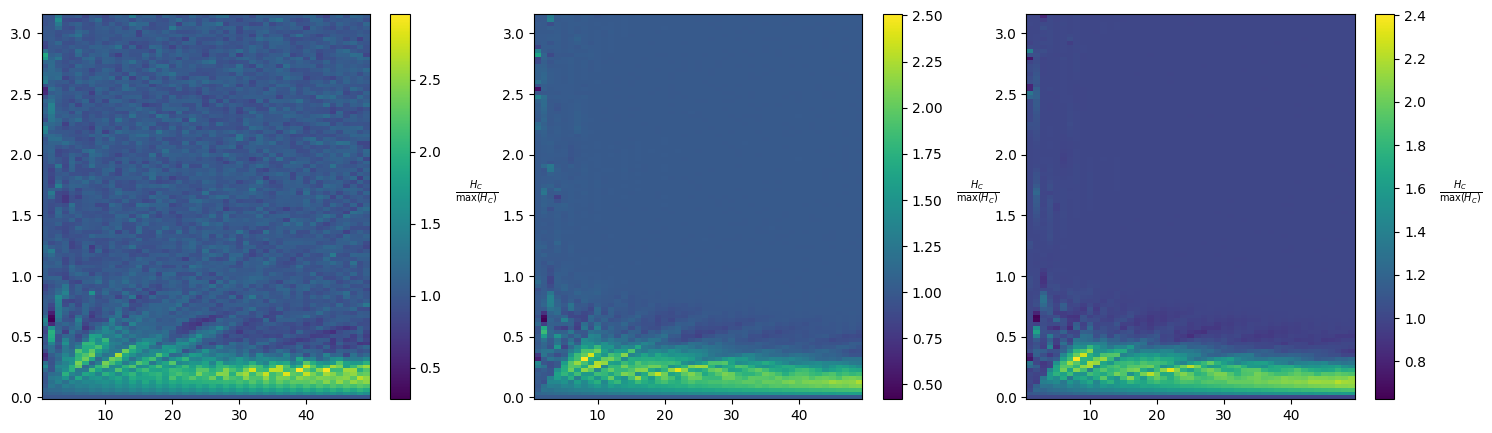

In [3]:
fig, axs = plt.subplots(1, 3)
ax0 = plot(axs[0], 'test_N2_W2', '3.14', '49', True)
ax1 = plot(axs[1],'trivial', '3.14', '49', True)
ax2 = plot(axs[2],'test_N3_W4', '3.14', '49', True)
fig.set_figheight(5)
fig.set_figwidth(18)

In [41]:
def plot_3d(axs, filename, maxdb, maxdg, maxp, normalise=True):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/LR_param_exploration.no_shot_noise.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))]    
    print(plot_ps)
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(delta_bs, delta_gs, energies[plot_ps[i],:,:].T, shading='nearest')
        ax.set_xlabel(r'$\Delta_\beta')
        ax.set_ylabel('$\\Delta_\\gamma')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = '$\\frac{H_C}{\\max(H_C)}$' if normalise else '${H_C}$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=25)
    return axs

[0, 7, 14, 21, 28]


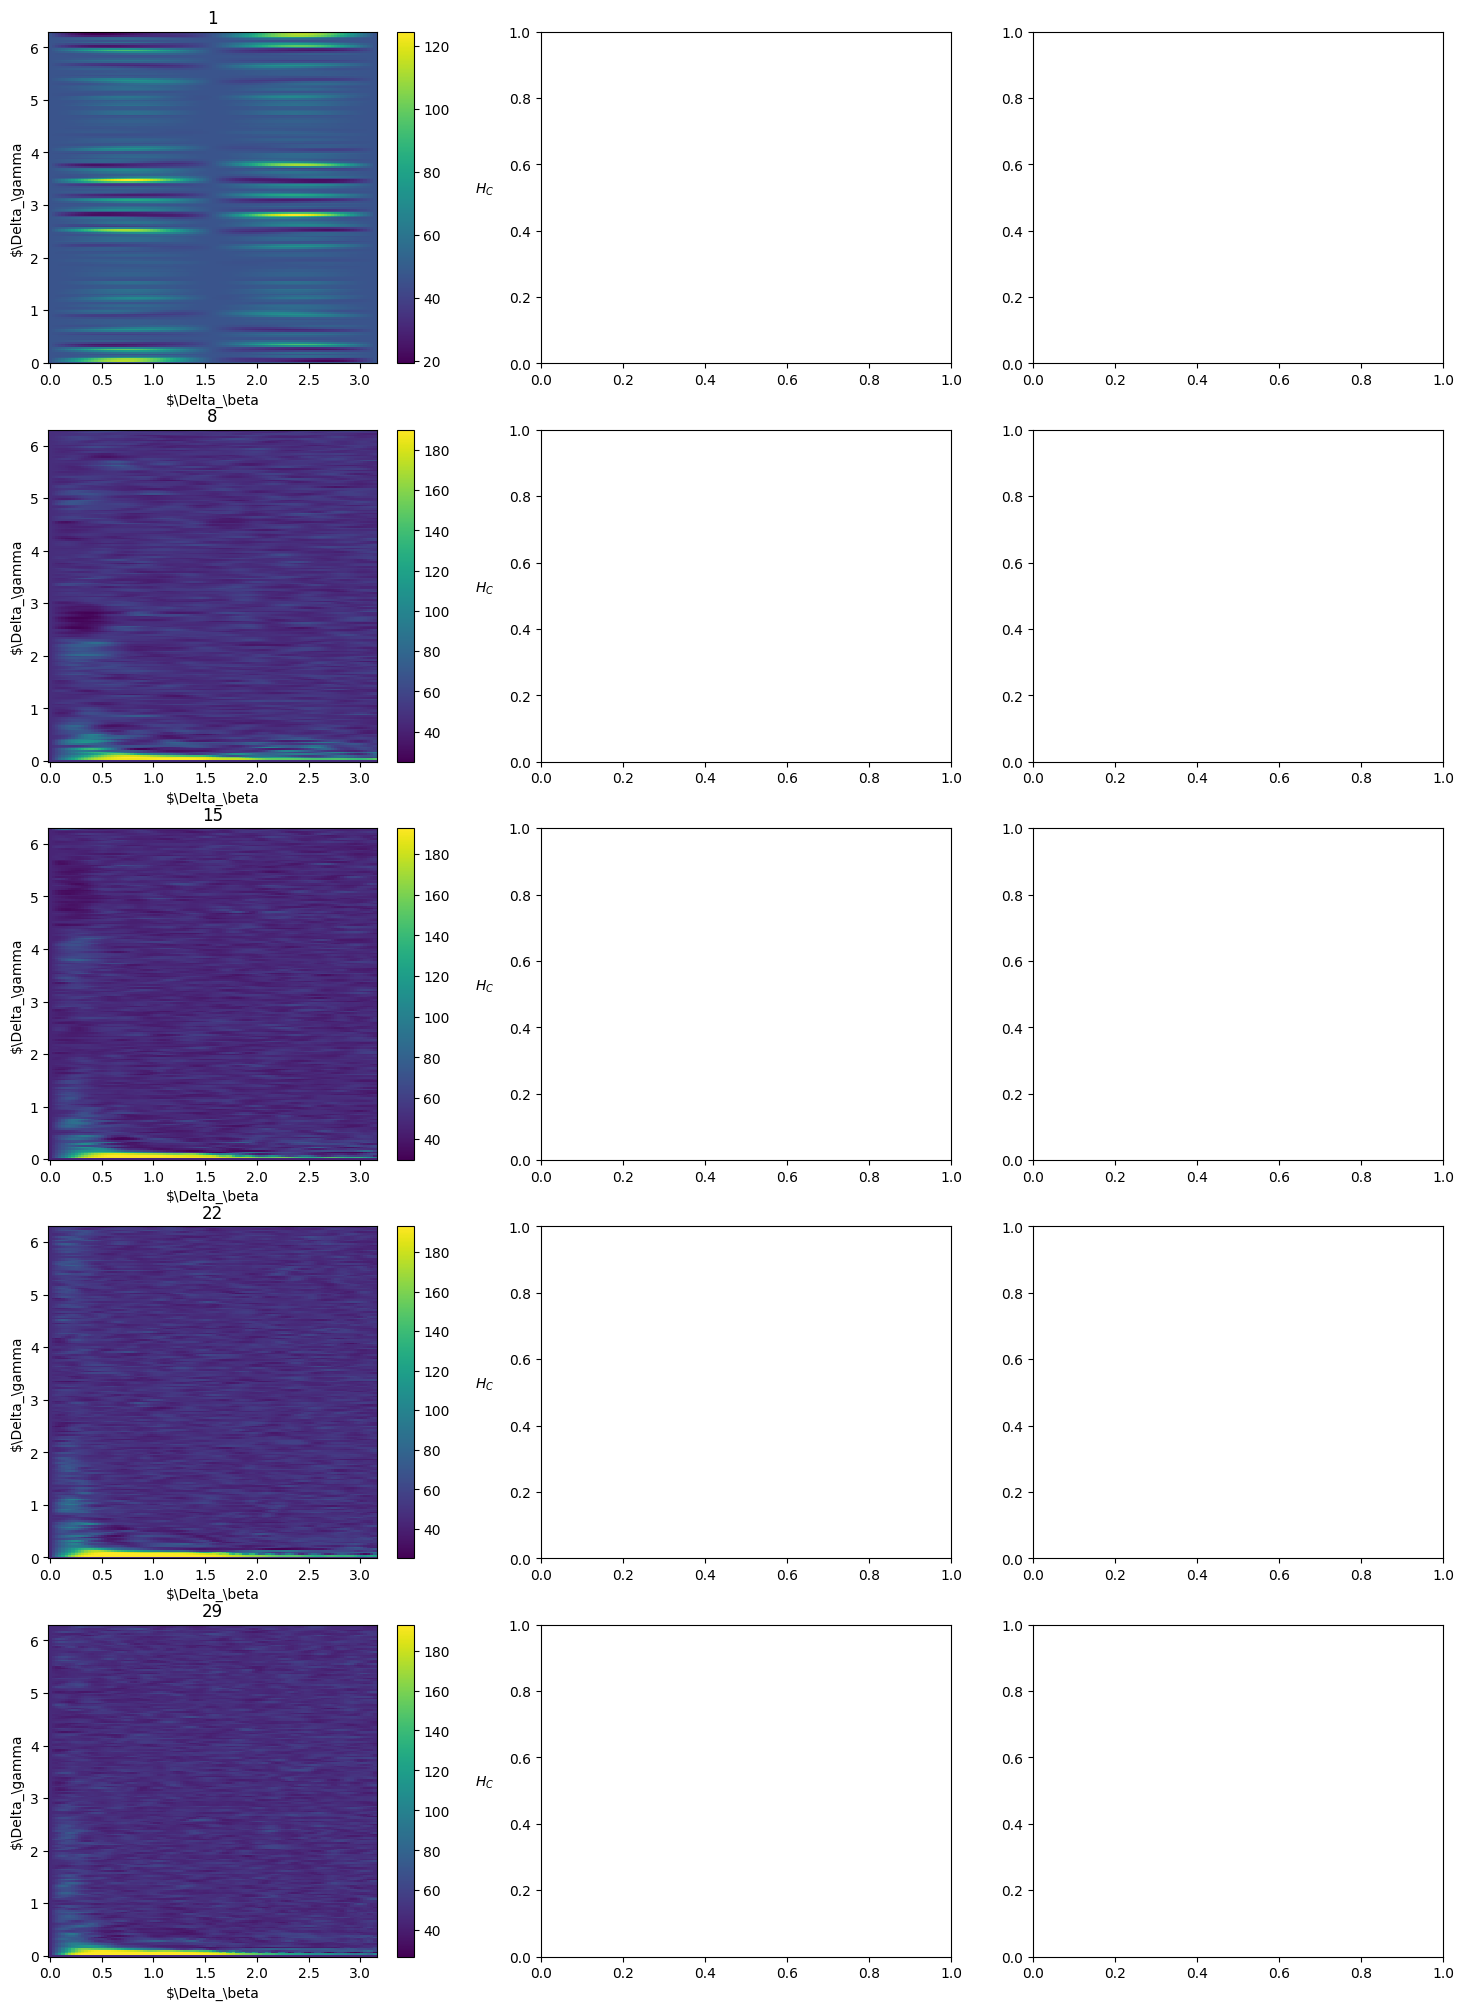

In [43]:
fig, axs = plt.subplots(5, 3)
axs0 = axs[:, 0]
axs1 = axs[:, 1]
axs2 = axs[:, 2]
axs0 = plot_3d(axs0, 'test_N2_W2', '3.14', '6.28', '29', False)
# axs0 = plot_3d(axs1, 'trivial', '3.14', '49', True)
# axs0 = plot_3d(axs2, 'test_N3_W4', '3.14', '49', True)
fig.set_figheight(25)
fig.set_figwidth(18)